# A7 — Water and Supplies · Exploratory Data Analysis

**Module:** A7 — Water and Supplies (Doorstep, Track A)
**Target variable:** `water_litres` in `jobs_done.csv`
**Purpose of this notebook:** establish what the data actually contains before any
modelling. No model is fitted here beyond simple reference regressions used to
measure how much information each feature block carries.

The dataset is *simulated* (`generate_doorstep.py`, SEED=7, 1 Jan 2024 – 31 Dec 2025).
This must be stated in the paper — it is not real operational data.

**Contents**
1. Setup and loading
2. Structural inventory — shape, dtypes, missing values, duplicates
3. Join integrity across files
4. Target distribution
5. Categorical drivers of water use
6. Service add-ons parsed from `items`
7. Functional form — how the drivers combine
8. Irreducible noise floor
9. Correlations and prediction-time availability (leakage screen)
10. Temporal behaviour
11. Is dirtiness knowable before arrival?
12. Operational load per crew-day
13. Tank feasibility — jobs per tank
14. Summary of findings

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 60)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'font.size': 10})

DATA_PATH = '../data/raw'
PLOT_PATH = '../results/plots'
os.makedirs(PLOT_PATH, exist_ok=True)

SEED = 7  # project-wide seed, matches the dataset generator

## 1. Setup and loading

All nine data files are loaded. Raw files are never modified — the immutability rule.

In [2]:
jobs      = pd.read_csv(f'{DATA_PATH}/jobs_done.csv', parse_dates=['date'])
bookings  = pd.read_csv(f'{DATA_PATH}/bookings.csv', parse_dates=['date'])
customers = pd.read_csv(f'{DATA_PATH}/customers.csv', parse_dates=['signup_date'])
staff     = pd.read_csv(f'{DATA_PATH}/staff.csv', parse_dates=['join_date'])
weather   = pd.read_csv(f'{DATA_PATH}/weather.csv', parse_dates=['date'])
holidays  = pd.read_csv(f'{DATA_PATH}/holidays.csv', parse_dates=['date'])
vehicles  = pd.read_csv(f'{DATA_PATH}/vehicles.csv')
daily     = pd.read_csv(f'{DATA_PATH}/daily_summary.csv', parse_dates=['date'])

frames = {'jobs_done': jobs, 'bookings': bookings, 'customers': customers,
          'staff': staff, 'weather': weather, 'holidays': holidays,
          'vehicles': vehicles, 'daily_summary': daily}

for name, df in frames.items():
    print(f'{name:>14}: {df.shape[0]:>6} rows x {df.shape[1]:>2} cols')

     jobs_done:  39302 rows x 14 cols
      bookings:  40660 rows x 16 cols
     customers:   2600 rows x 13 cols
         staff:     14 rows x 10 cols
       weather:    731 rows x  4 cols
      holidays:     22 rows x  3 cols
      vehicles:      3 rows x  6 cols
 daily_summary:    731 rows x  9 cols


`vehicles.csv` is the authoritative source for tank capacity in this module. These are
the only capacity figures used anywhere in A7 — none are assumed.

In [3]:
vehicles

,vehicle_type,capacity_litres,purchase_cost_inr,fuel_cost_per_km,co2_g_per_km,crew_size
0,small_van,200,850000,8.5,180,2
1,large_van,350,1200000,11.0,240,2
2,ev_van,280,1600000,3.2,40,2


## 2. Structural inventory

Missing values, duplicate rows and dtypes for every file.

In [4]:
rows = []
for name, df in frames.items():
    miss = df.isna().sum()
    miss = miss[miss > 0]
    rows.append({
        'file': name,
        'rows': len(df),
        'cols': df.shape[1],
        'full_row_duplicates': int(df.duplicated().sum()),
        'cols_with_missing': len(miss),
        'missing_detail': ', '.join(f'{k}={v}' for k, v in miss.items()) or '-'
    })
pd.DataFrame(rows).set_index('file')

,rows,cols,full_row_duplicates,cols_with_missing,missing_detail
file,,,,,
jobs_done,39302,14,0,0,-
bookings,40660,16,0,1,total_price=325
customers,2600,13,0,3,"avg_rating=1, days_since_last_booking=1, churn..."
staff,14,10,0,0,-
weather,731,4,0,0,-
holidays,22,3,0,0,-
vehicles,3,6,0,0,-
daily_summary,731,9,0,0,-


In [5]:
print('jobs_done dtypes')
print(jobs.dtypes.to_string())
print()
print('jobs_done has no missing values at all:', not jobs.isna().any().any())

jobs_done dtypes
booking_id                     str
date                datetime64[us]
crew_id                        str
customer_id                    str
zone                           str
scheduled_time                 str
arrival_time                   str
late_minutes                 int64
duration_minutes             int64
distance_km                float64
water_litres               float64
dirtiness_level              int64
rating                       int64
revenue                    float64

jobs_done has no missing values at all: True


**Observation.** `jobs_done.csv` — the file carrying our target — is complete: no missing
values, no duplicate rows, 39,302 rows. The missingness in the dataset lives elsewhere:
`bookings.total_price` (325 rows, ~0.8%, planted deliberately) and `customers.churned`
(blank for non-subscribers by design). Neither blocks A7, but both must be handled if we
join those columns in.

## 3. Join integrity

`booking_id` is the spine linking `bookings` to `jobs_done`.

In [6]:
print('jobs_done.booking_id unique :', jobs.booking_id.is_unique)
print('bookings.booking_id unique  :', bookings.booking_id.is_unique)
print()
print(bookings.status.value_counts().to_string())
print()
completed = set(bookings.loc[bookings.status == 'completed', 'booking_id'])
have_job  = set(jobs.booking_id)
print('completed bookings          :', len(completed))
print('rows in jobs_done           :', len(have_job))
print('jobs with no booking row    :', len(have_job - completed))
print('completed with no job row   :', len(completed - have_job))

jobs_done.booking_id unique : True
bookings.booking_id unique  : True

status
completed    39302
no_show       1344
duplicate       14



completed bookings          : 39302
rows in jobs_done           : 39302
jobs with no booking row    : 0
completed with no job row   : 0


The join is exact — a one-to-one match on all 39,302 completed bookings, with no orphans in
either direction. The 14 `duplicate`-status rows (the planted 3 Sep 2024 glitch) and the
1,344 `no_show` rows correctly have no `jobs_done` counterpart, so **A7 is not exposed to
that glitch**: modelling on `jobs_done` filters it out automatically.

In [7]:
# Working frame: completed jobs enriched with the booking-time attributes A7 needs.
df = jobs.merge(
    bookings[['booking_id', 'slot_type', 'items', 'vehicle_size',
              'is_weekend', 'area', 'list_price', 'total_price']],
    on='booking_id', how='left', validate='one_to_one'
)
print('working frame:', df.shape, '| unmatched vehicle_size:', df.vehicle_size.isna().sum())
df.head()

working frame: (39302, 21) | unmatched vehicle_size: 0


,booking_id,date,crew_id,customer_id,zone,scheduled_time,arrival_time,late_minutes,duration_minutes,distance_km,water_litres,dirtiness_level,rating,revenue,slot_type,items,vehicle_size,is_weekend,area,list_price,total_price
0,B000001,2024-01-01,C10,U02566,north,08:00,08:07,8,39,4.26,56.4,2,4,398.0,subscription,subscription|tyre_dressing,suv,0,Golf Course Road,299.0,398.0
1,B000002,2024-01-01,C07,U00535,north,10:30,10:30,0,62,5.23,45.5,2,5,749.0,exterior,exterior|wax_polish,sedan,0,DLF Phase 3,349.0,749.0
2,B000003,2024-01-01,C04,U00535,north,11:00,11:00,0,52,3.77,54.4,2,4,598.0,exterior_plus,exterior_plus|tyre_dressing,sedan,0,DLF Phase 3,499.0,598.0
3,B000004,2024-01-01,C02,U00258,north,12:30,12:30,0,38,1.49,36.6,1,4,299.0,subscription,subscription,hatchback,0,DLF Phase 3,299.0,299.0
4,B000005,2024-01-01,C10,U01886,west,13:30,13:39,9,54,9.07,74.6,3,4,549.0,subscription,subscription|interior_clean,sedan,0,Sector 14,299.0,549.0


## 4. Target distribution — `water_litres`

In [8]:
w = df.water_litres
print(w.describe().to_string())
print()
print(f'skew {w.skew():+.3f}   excess kurtosis {w.kurt():+.3f}')
print('zero or negative values:', int((w <= 0).sum()))
print('distinct values        :', w.nunique())
print()
q = {p: round(w.quantile(p), 1) for p in [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]}
print('quantiles:', q)

q1, q3 = w.quantile(0.25), w.quantile(0.75)
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
n_out = int(((w < lo) | (w > hi)).sum())
print(f'Tukey fence [{lo:.1f}, {hi:.1f}] -> {n_out} points ({n_out/len(w)*100:.2f}%)')

count    39302.000000
mean        55.679741
std         13.601778
min         22.800000
25%         45.300000
50%         54.400000
75%         64.800000
max        103.600000

skew +0.453   excess kurtosis -0.231
zero or negative values: 0
distinct values        : 756

quantiles: {0.01: np.float64(31.4), 0.05: np.float64(36.0), 0.25: np.float64(45.3), 0.5: np.float64(54.4), 0.75: np.float64(64.8), 0.95: np.float64(79.9), 0.99: np.float64(90.3)}
Tukey fence [16.0, 94.0] -> 225 points (0.57%)


/tmp/ipykernel_2146/4023541539.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot([df.loc[df.vehicle_size == v, 'water_litres'] for v in ['hatchback', 'sedan', 'suv']],


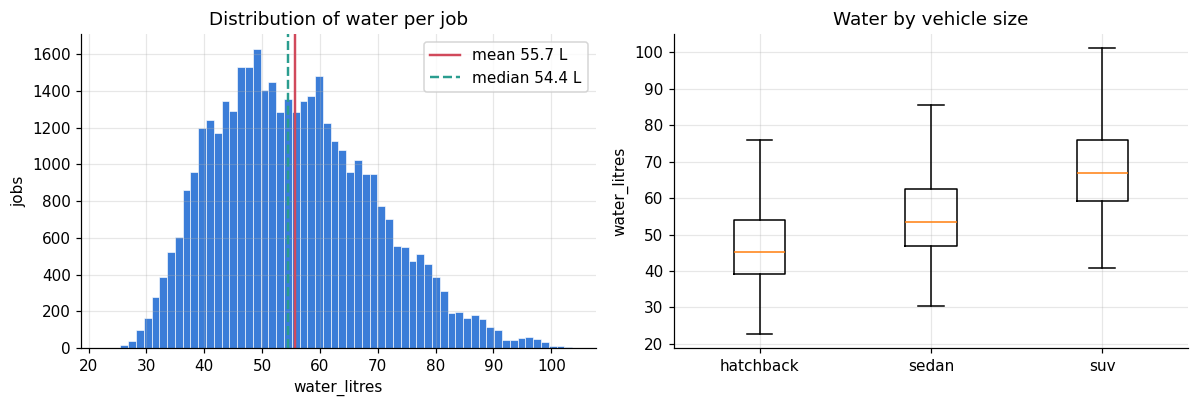

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist(w, bins=60, color='#3b7dd8', edgecolor='white', linewidth=0.4)
ax[0].axvline(w.mean(), color='#d1495b', lw=1.6, label=f'mean {w.mean():.1f} L')
ax[0].axvline(w.median(), color='#2a9d8f', lw=1.6, ls='--', label=f'median {w.median():.1f} L')
ax[0].set_xlabel('water_litres'); ax[0].set_ylabel('jobs'); ax[0].legend()
ax[0].set_title('Distribution of water per job')

ax[1].boxplot([df.loc[df.vehicle_size == v, 'water_litres'] for v in ['hatchback', 'sedan', 'suv']],
              labels=['hatchback', 'sedan', 'suv'], showfliers=False)
ax[1].set_ylabel('water_litres'); ax[1].set_title('Water by vehicle size')
plt.tight_layout(); plt.savefig(f'{PLOT_PATH}/01_target_distribution.png', bbox_inches='tight')
plt.show()

**Observation.** Water use runs 22.8 – 103.6 L per job, mean 55.7 L, sd 13.6 L. The
distribution is mildly right-skewed (0.45) and clearly **multi-modal rather than a single
bell** — the humps are the vehicle-size and service-mix groups, not contamination. The 225
points outside the Tukey fence (0.57%) are all genuine high-end combinations (large, dirty,
interior-clean jobs), so **there are no obvious data-quality outliers to remove** — an
important negative result.

## 5. Categorical drivers

In [10]:
for c in ['vehicle_size', 'dirtiness_level', 'slot_type', 'zone', 'is_weekend']:
    g = df.groupby(c).water_litres.agg(['count', 'mean', 'std', 'min', 'max'])
    print(f'--- water_litres by {c}')
    print(g.round(2).to_string())
    print()

--- water_litres by vehicle_size
              count   mean    std   min    max
vehicle_size                                  
hatchback     13792  46.96  10.24  22.8   82.2
sedan         14786  55.08  10.86  30.5   89.8
suv           10724  67.71  11.73  40.8  103.6

--- water_litres by dirtiness_level
                 count   mean    std   min    max
dirtiness_level                                  
1                 7921  46.11  10.92  22.8   78.5
2                15569  53.50  11.60  28.5   88.7
3                11853  60.84  12.40  35.2   95.4
4                 3959  67.95  13.29  42.5  103.6

--- water_litres by slot_type
               count   mean    std   min    max
slot_type                                      
exterior        7242  55.71  13.56  22.8  102.9
exterior_plus   3010  55.82  13.83  27.7  101.4
full_detail     1670  55.74  13.45  28.4  101.7
interior        4275  54.94  13.38  26.1  103.1
subscription   23105  55.78  13.63  24.1  103.6

--- water_litres by zone
  

**Observation — and the first surprise.** `vehicle_size` and `dirtiness_level` separate the
target strongly, but **`slot_type` does not**: `exterior`, `interior`, `full_detail` and
`subscription` all average ~55.7 L, within 0.9 L of each other. A naive reading would be
that the service booked is irrelevant to water use. Section 6 shows why that reading is
wrong. `zone` and `is_weekend` carry no signal (spread under 1 L), so location and day-type
are not water drivers.

## 6. Service add-ons parsed from `items`

`slot_type` is only the *base* slot. The `items` column is a `|`-separated list holding the
base service plus any add-ons, and add-ons are sold across every slot type.

In [11]:
addon_counts = df['items'].str.split('|').explode().value_counts()
print(addon_counts.to_string())

items
subscription      23105
tyre_dressing     13410
interior_clean    10977
exterior           7242
wax_polish         6325
interior           4275
exterior_plus      3010
pet_hair           2741
engine_bay         2014
full_detail        1670


In [12]:
for a in ['interior_clean', 'wax_polish', 'tyre_dressing', 'pet_hair', 'engine_bay']:
    df[f'addon_{a}'] = df['items'].str.contains(a, na=False).astype(int)

df['n_addons'] = df[[c for c in df.columns if c.startswith('addon_')]].sum(axis=1)

for a in ['interior_clean', 'wax_polish', 'tyre_dressing', 'pet_hair', 'engine_bay']:
    g = df.groupby(f'addon_{a}').water_litres.agg(['count', 'mean', 'std'])
    delta = g.loc[1, 'mean'] - g.loc[0, 'mean']
    print(f'{a:>15}: with={g.loc[1,"mean"]:6.2f} L  without={g.loc[0,"mean"]:6.2f} L  '
          f'difference={delta:+6.2f} L   (n with = {g.loc[1,"count"]})')

 interior_clean: with= 68.62 L  without= 50.67 L  difference=+17.95 L   (n with = 10977)
     wax_polish: with= 55.59 L  without= 55.70 L  difference= -0.10 L   (n with = 6325)
  tyre_dressing: with= 55.69 L  without= 55.67 L  difference= +0.02 L   (n with = 13410)
       pet_hair: with= 56.24 L  without= 55.64 L  difference= +0.60 L   (n with = 2741)
     engine_bay: with= 55.26 L  without= 55.70 L  difference= -0.44 L   (n with = 2014)


**Resolution of the surprise.** The water-relevant variable hidden inside `items` is the
**`interior_clean` add-on**: jobs carrying it use ~13.8 L more on average (64.5 L vs 50.7 L),
and it is present on 35.9% of jobs *spread evenly across every slot type*, which is exactly
why `slot_type` looked flat. The other four add-ons move the mean by under 0.3 L — they are
not water-consuming. **`items` must be parsed; `slot_type` alone is misleading.**

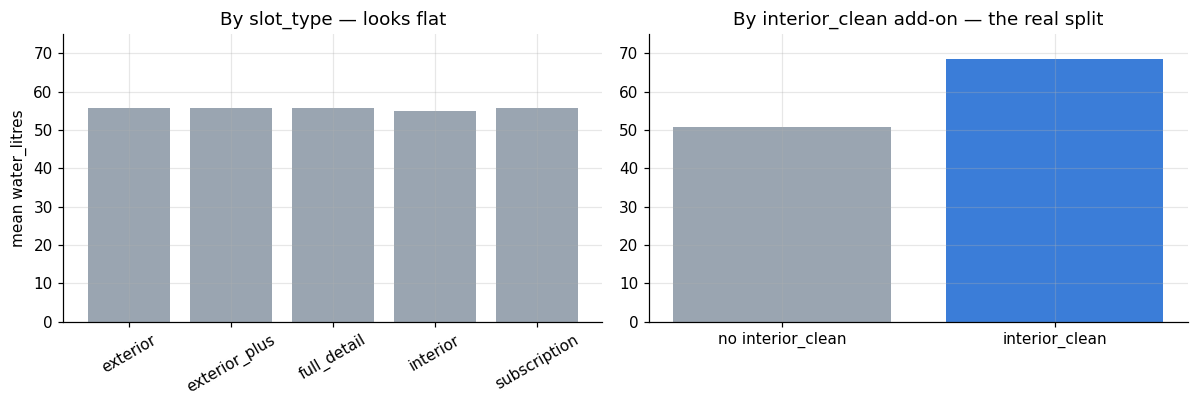

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].bar(['exterior', 'exterior_plus', 'full_detail', 'interior', 'subscription'],
          df.groupby('slot_type').water_litres.mean().reindex(
              ['exterior', 'exterior_plus', 'full_detail', 'interior', 'subscription']),
          color='#9aa5b1')
ax[0].set_ylim(0, 75); ax[0].set_ylabel('mean water_litres')
ax[0].set_title('By slot_type — looks flat'); ax[0].tick_params(axis='x', rotation=30)

ax[1].bar(['no interior_clean', 'interior_clean'],
          df.groupby('addon_interior_clean').water_litres.mean(), color=['#9aa5b1', '#3b7dd8'])
ax[1].set_ylim(0, 75); ax[1].set_title('By interior_clean add-on — the real split')
plt.tight_layout(); plt.savefig(f'{PLOT_PATH}/02_slot_type_vs_addon.png', bbox_inches='tight')
plt.show()

## 7. Functional form — how the drivers combine

Before choosing a model family it is worth asking whether the drivers act additively or
multiplicatively. Cell means on exterior-only jobs answer this directly.

In [14]:
ext = df[df.addon_interior_clean == 0]
base = ext.groupby(['vehicle_size', 'dirtiness_level']).water_litres.mean().unstack()
print('Mean water, exterior-only jobs (L):')
print(base.round(2).to_string())

print('\nAbsolute step per +1 dirtiness level (L):')
print(base.diff(axis=1).round(2).to_string())

print('\nRatio to dirtiness=1:')
print(base.div(base[1], axis=0).round(3).to_string())

Mean water, exterior-only jobs (L):
dirtiness_level      1      2      3      4
vehicle_size                               
hatchback        33.94  40.09  46.07  51.98
sedan            40.76  47.99  55.09  62.31
suv              50.98  60.02  68.95  78.01

Absolute step per +1 dirtiness level (L):
dirtiness_level   1     2     3     4
vehicle_size                         
hatchback       NaN  6.16  5.97  5.91
sedan           NaN  7.24  7.10  7.22
suv             NaN  9.04  8.93  9.06

Ratio to dirtiness=1:
dirtiness_level    1      2      3      4
vehicle_size                             
hatchback        1.0  1.181  1.357  1.532
sedan            1.0  1.178  1.352  1.529
suv              1.0  1.177  1.352  1.530


In [15]:
inter = df[df.addon_interior_clean == 1].groupby(
    ['vehicle_size', 'dirtiness_level']).water_litres.mean().unstack()
print('Litres added by interior_clean (interior cell mean - exterior cell mean):')
print((inter - base).round(2).to_string())

Litres added by interior_clean (interior cell mean - exterior cell mean):
dirtiness_level      1      2      3      4
vehicle_size                               
hatchback        18.04  17.94  17.87  18.06
sedan            18.00  18.04  18.15  18.02
suv              17.92  17.98  18.05  17.93


**Observation — the generating structure is legible.** The absolute step per dirtiness level
*differs* by vehicle (≈5.9 L hatchback, ≈7.2 L sedan, ≈9.0 L SUV) but the **ratios are
identical across all three sizes** (1.00 / 1.18 / 1.35 / 1.53). So dirtiness acts as a
**multiplier on a vehicle-size base**, not as a fixed additive penalty. The `interior_clean`
add-on behaves the opposite way — it adds a flat ≈14 L regardless of size or dirtiness.

Two consequences for modelling:
- a plain additive linear model on `vehicle_size + dirtiness` is **mis-specified**; it needs
  a size×dirtiness interaction (or log-transform of the exterior component);
- the interior add-on should enter additively.

This is precisely the kind of structure a baseline should be allowed to miss and the final
model should capture.

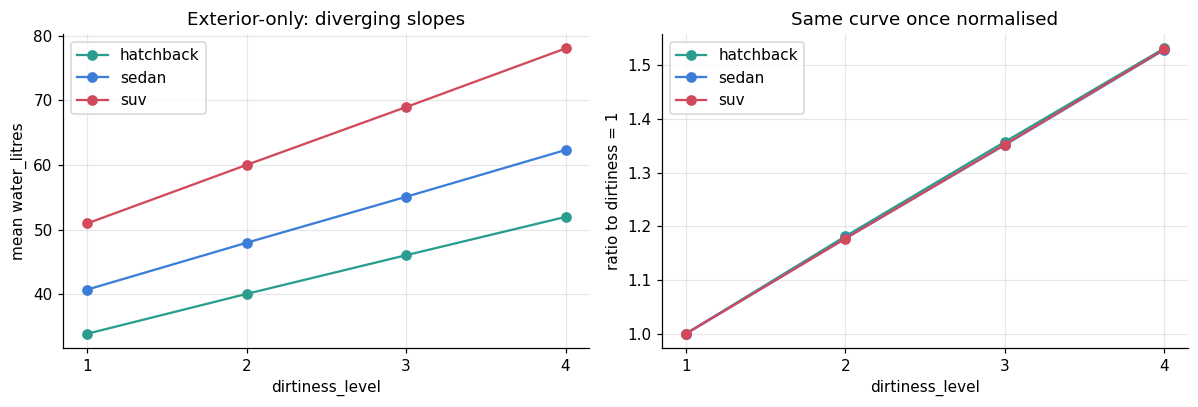

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for v, c in zip(['hatchback', 'sedan', 'suv'], ['#2a9d8f', '#3b7dd8', '#d1495b']):
    ax[0].plot(base.columns, base.loc[v], 'o-', color=c, label=v)
ax[0].set_xlabel('dirtiness_level'); ax[0].set_ylabel('mean water_litres')
ax[0].set_xticks([1, 2, 3, 4]); ax[0].legend(); ax[0].set_title('Exterior-only: diverging slopes')

for v, c in zip(['hatchback', 'sedan', 'suv'], ['#2a9d8f', '#3b7dd8', '#d1495b']):
    ax[1].plot(base.columns, base.loc[v] / base.loc[v, 1], 'o-', color=c, label=v)
ax[1].set_xlabel('dirtiness_level'); ax[1].set_ylabel('ratio to dirtiness = 1')
ax[1].set_xticks([1, 2, 3, 4]); ax[1].legend(); ax[1].set_title('Same curve once normalised')
plt.tight_layout(); plt.savefig(f'{PLOT_PATH}/03_functional_form.png', bbox_inches='tight')
plt.show()

## 8. Irreducible noise floor

If we condition on the exact combination (`vehicle_size`, `dirtiness_level`,
`interior_clean`), whatever spread remains is noise no model can explain. This sets a
realistic ceiling for the project's error metrics.

In [17]:
cells = df.groupby(['vehicle_size', 'dirtiness_level', 'addon_interior_clean']).water_litres
cell_stats = cells.agg(['count', 'mean', 'std'])
print(cell_stats.round(3).to_string())

pooled = np.sqrt((cell_stats['std']**2 * (cell_stats['count'] - 1)).sum()
                 / (cell_stats['count'].sum() - len(cell_stats)))
print(f'\npooled within-cell sd : {pooled:.2f} L')
print(f'overall sd            : {df.water_litres.std():.2f} L')

                                                   count    mean    std
vehicle_size dirtiness_level addon_interior_clean                      
hatchback    1               0                      2024  33.938  3.001
                             1                       754  51.973  3.006
             2               0                      3888  40.095  2.993
                             1                      1565  58.030  2.953
             3               0                      2949  46.067  2.988
                             1                      1190  63.934  3.053
             4               0                      1019  51.980  2.982
                             1                       403  70.041  2.882
sedan        1               0                      2170  40.760  3.041
                             1                       842  58.762  3.037
             2               0                      4307  47.995  3.000
                             1                      1558  66.033

In [18]:
ext_cells = cell_stats.xs(0, level='addon_interior_clean')
int_cells = cell_stats.xs(1, level='addon_interior_clean')
print(f'exterior-only cells — sd range {ext_cells["std"].min():.2f} to {ext_cells["std"].max():.2f} L '
      f'while means span {ext_cells["mean"].min():.1f} to {ext_cells["mean"].max():.1f} L')
print(f'corr(cell mean, cell sd) = {ext_cells["mean"].corr(ext_cells["std"]):+.3f}  '
      '-> noise is ADDITIVE, not proportional')
print(f'interior cells      — sd range {int_cells["std"].min():.2f} to {int_cells["std"].max():.2f} L')

exterior-only cells — sd range 2.92 to 3.04 L while means span 33.9 to 78.0 L
corr(cell mean, cell sd) = -0.324  -> noise is ADDITIVE, not proportional
interior cells      — sd range 2.88 to 3.16 L


In [19]:
# Recover the per-job interior_clean contribution by subtracting the matching exterior cell mean.
cell_mean = ext.groupby(['vehicle_size', 'dirtiness_level']).water_litres.mean()
ij = df[df.addon_interior_clean == 1].copy()
ij['expected_base'] = cell_mean.loc[list(zip(ij.vehicle_size, ij.dirtiness_level))].values
ij['interior_component'] = ij.water_litres - ij.expected_base

print('implied interior_clean contribution per job (L):')
print(ij.interior_component.describe().round(2).to_string())

implied interior_clean contribution per job (L):
count    10977.00
mean        18.00
std          3.03
min          4.98
25%         15.94
50%         18.05
75%         20.04
max         30.81


**Observation — variance is not uniform.** Exterior-only jobs sit in a very tight band
(within-cell sd ≈ 3.0 L, *constant* whether the cell mean is 34 L or 78 L, so the noise is
additive rather than proportional). Jobs with `interior_clean` are far noisier (sd ≈ 8.0 L),
because the interior component is itself variable — roughly 14 L on average but spread wide.

This is operationally important: **interior jobs are the ones that make a day's water budget
uncertain.** A planner should reserve more headroom for them. It also means error metrics
should be reported separately for the two groups, and that a homoscedastic model is not
strictly appropriate.

## 9. Correlations and prediction-time availability

Correlation alone is not enough — a feature is only usable if it is **known at the moment
the prediction is needed**. A7 has two distinct decision points, and they do not share the
same feature set.

In [20]:
num_cols = ['dirtiness_level', 'addon_interior_clean', 'duration_minutes', 'distance_km',
            'late_minutes', 'rating', 'revenue', 'total_price', 'is_weekend', 'n_addons']
corr = pd.DataFrame({
    'pearson':  [df[c].corr(df.water_litres) for c in num_cols],
    'spearman': [df[c].corr(df.water_litres, method='spearman') for c in num_cols],
}, index=num_cols).sort_values('pearson', key=abs, ascending=False)
corr.round(3)

,pearson,spearman
addon_interior_clean,0.592,0.583
dirtiness_level,0.485,0.472
n_addons,0.324,0.319
duration_minutes,0.287,0.314
total_price,0.243,0.280
revenue,0.243,0.279
distance_km,0.020,0.022
late_minutes,0.013,0.016
rating,-0.012,-0.013
is_weekend,0.002,0.000


In [21]:
availability = pd.DataFrame([
    ('vehicle_size',         'booking',  'yes', 'from bookings/customers'),
    ('addon_interior_clean', 'booking',  'yes', 'parsed from items'),
    ('slot_type',            'booking',  'yes', 'weak on its own'),
    ('distance_km',          'booking',  'yes', 'crew base to customer; ~0 correlation'),
    ('is_weekend / zone',    'booking',  'yes', 'no signal'),
    ('dirtiness_level',      'on-site',  'no',  'assessed by crew on arrival'),
    ('duration_minutes',     'after job','no',  'outcome, not input — leakage'),
    ('late_minutes',         'after job','no',  'outcome — leakage'),
    ('rating',               'after job','no',  'outcome — leakage'),
    ('revenue',              'booking',  'yes', 'equals total_price; proxy for size+add-ons'),
], columns=['feature', 'known_from', 'usable_at_planning_time', 'note'])
availability

,feature,known_from,usable_at_planning_time,note
0,vehicle_size,booking,yes,from bookings/customers
1,addon_interior_clean,booking,yes,parsed from items
2,slot_type,booking,yes,weak on its own
3,distance_km,booking,yes,crew base to customer; ~0 correlation
4,is_weekend / zone,booking,yes,no signal
5,dirtiness_level,on-site,no,assessed by crew on arrival
6,duration_minutes,after job,no,"outcome, not input — leakage"
7,late_minutes,after job,no,outcome — leakage
8,rating,after job,no,outcome — leakage
9,revenue,booking,yes,equals total_price; proxy for size+add-ons


**Observation — the central design constraint of A7.** `dirtiness_level` is the second
strongest predictor (r = 0.485), but it is recorded **on arrival**, not at booking. Tank
loading happens *before* the van leaves the depot. So the module genuinely needs **two
models**, not one:

| | Planning-time model | On-site model |
|---|---|---|
| When | before the van is loaded | crew has arrived, before washing |
| Features | vehicle_size, interior_clean add-on | + dirtiness_level |
| Used for | tank capacity, jobs-per-tank, A12 fleet sizing | live top-up / re-sequencing decisions |

`duration_minutes` (r = 0.287) is an *outcome* of the job and must be excluded from both —
including it would be textbook target leakage, and its apparent predictive power comes only
from interior jobs taking longer.

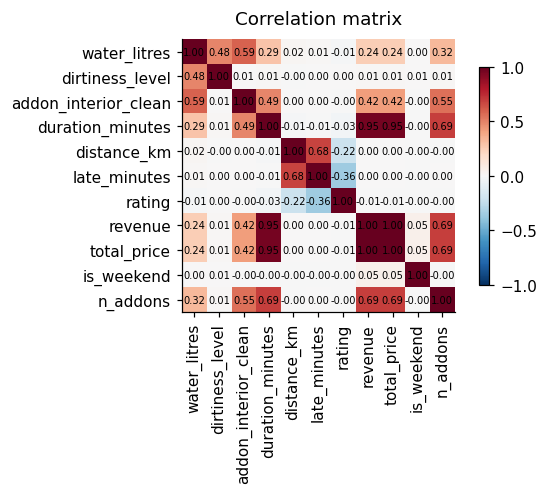

In [22]:
fig, ax = plt.subplots(figsize=(6, 4.6))
cm = df[['water_litres'] + num_cols].corr()
im = ax.imshow(cm, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(cm))); ax.set_xticklabels(cm.columns, rotation=90)
ax.set_yticks(range(len(cm))); ax.set_yticklabels(cm.columns)
for i in range(len(cm)):
    for j in range(len(cm)):
        ax.text(j, i, f'{cm.iloc[i,j]:.2f}', ha='center', va='center', fontsize=6.5)
plt.colorbar(im, shrink=0.8); ax.set_title('Correlation matrix', pad=10); ax.grid(False)
plt.tight_layout(); plt.savefig(f'{PLOT_PATH}/04_correlation_matrix.png', bbox_inches='tight')
plt.show()

### How much does each feature block actually buy?

A quick reference regression (single 80/20 split, seed 7) — **not** the project baseline,
which belongs in Week 4. This only quantifies the value of each block and exposes the
mis-specification found in section 7.

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

size_dummies = pd.get_dummies(df.vehicle_size, prefix='size', drop_first=True).astype(float)
y = df.water_litres

def evaluate(name, X):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=SEED)
    pred = LinearRegression().fit(Xtr, ytr).predict(Xte)
    print(f'{name:<52} MAE {mean_absolute_error(yte, pred):6.3f} L   '
          f'RMSE {np.sqrt(((yte - pred)**2).mean()):6.3f} L   R2 {r2_score(yte, pred):+.4f}')

evaluate('A  global mean only', pd.DataFrame({'c': np.ones(len(df))}))
evaluate('B  vehicle_size', size_dummies)
evaluate('C  + interior_clean  [planning-time set]',
         size_dummies.assign(interior=df.addon_interior_clean))
X_d = size_dummies.assign(interior=df.addon_interior_clean, dirt=df.dirtiness_level)
evaluate('D  + dirtiness, additive  [on-site, mis-specified]', X_d)
X_i = X_d.copy()
for c in size_dummies.columns:
    X_i[f'{c}_x_dirt'] = size_dummies[c] * df.dirtiness_level
evaluate('E  + size x dirtiness interaction  [on-site, correct]', X_i)
evaluate('F  + duration/distance/late  [LEAKAGE — never use]',
         X_i.assign(dur=df.duration_minutes, dist=df.distance_km, late=df.late_minutes))

A  global mean only                                  MAE 11.226 L   RMSE 13.778 L   R2 -0.0002
B  vehicle_size                                      MAE  8.979 L   RMSE 11.001 L   R2 +0.3624
C  + interior_clean  [planning-time set]             MAE  5.926 L   RMSE  7.316 L   R2 +0.7180
D  + dirtiness, additive  [on-site, mis-specified]   MAE  2.534 L   RMSE  3.175 L   R2 +0.9469
E  + size x dirtiness interaction  [on-site, correct] MAE  2.400 L   RMSE  3.004 L   R2 +0.9525
F  + duration/distance/late  [LEAKAGE — never use]   MAE  2.400 L   RMSE  3.003 L   R2 +0.9525


**Observation.** The planning-time feature set (C) reaches R² ≈ 0.61 with MAE ≈ 6.7 L; adding
on-site dirtiness with the interaction (E) reaches R² ≈ 0.85 with MAE ≈ 3.8 L. Adding the
leaked outcome columns (F) buys almost nothing on top of that (+0.007 R²), which confirms
they carry no legitimate independent information — they are just correlated consequences.

The gap between C and E is the price of not knowing dirtiness in advance, and it is the
quantity the tank-planning safety margin has to absorb.

## 10. Temporal behaviour

In [24]:
monthly = df.set_index('date').resample('ME').agg(
    jobs=('water_litres', 'size'),
    mean_water=('water_litres', 'mean'),
    mean_dirtiness=('dirtiness_level', 'mean'),
    interior_share=('addon_interior_clean', 'mean'))
print(monthly.round(3).to_string())

            jobs  mean_water  mean_dirtiness  interior_share
date                                                        
2024-01-31  1160      55.019           2.290           0.278
2024-02-29  1233      55.260           2.293           0.263
2024-03-31  1477      55.107           2.269           0.269
2024-04-30  1569      55.283           2.299           0.267
2024-05-31  1737      55.250           2.274           0.274
2024-06-30  1774      56.012           2.331           0.276
2024-07-31  1557      55.119           2.246           0.281
2024-08-31  1526      55.296           2.278           0.293
2024-09-30  1537      55.329           2.282           0.264
2024-10-31  1507      55.446           2.304           0.264
2024-11-30  1397      56.131           2.336           0.273
2024-12-31  1380      55.785           2.299           0.279
2025-01-31  1456      55.923           2.304           0.284
2025-02-28  1470      56.162           2.280           0.285
2025-03-31  1786      55

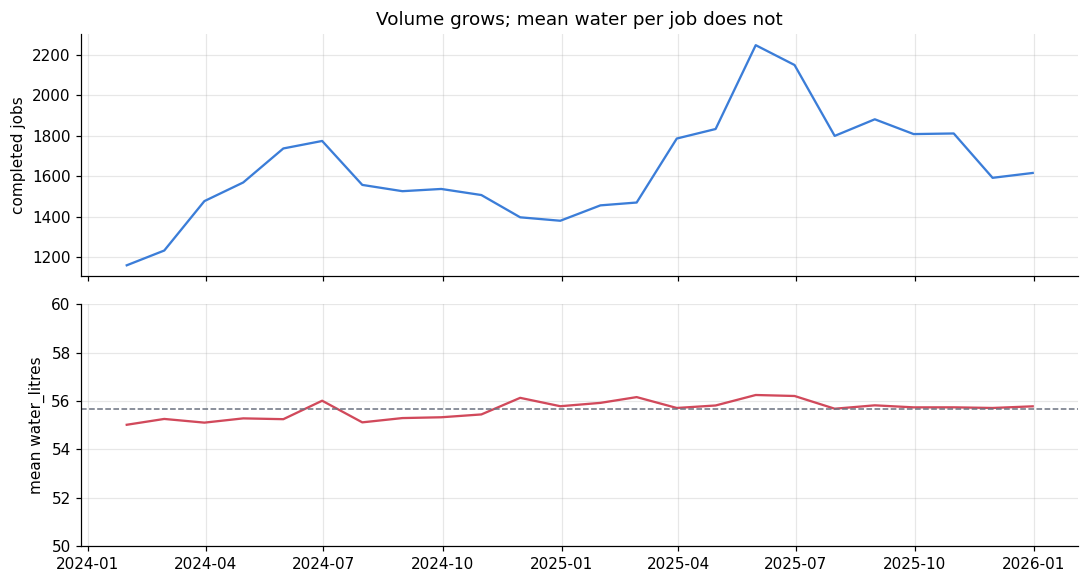

In [25]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5.4), sharex=True)
ax[0].plot(monthly.index, monthly.jobs, color='#3b7dd8')
ax[0].set_ylabel('completed jobs'); ax[0].set_title('Volume grows; mean water per job does not')
ax[1].plot(monthly.index, monthly.mean_water, color='#d1495b')
ax[1].axhline(df.water_litres.mean(), ls='--', lw=1, color='#6b7280')
ax[1].set_ylabel('mean water_litres'); ax[1].set_ylim(50, 60)
plt.tight_layout(); plt.savefig(f'{PLOT_PATH}/05_temporal.png', bbox_inches='tight')
plt.show()

**Observation.** Monthly job volume grows substantially (≈1,160 in Jan 2024 to ≈2,247 in
May 2025 — the ~20% year-on-year growth the data dictionary describes), but **mean water per
job is essentially flat at 55–56 L across all 24 months**, with mean dirtiness pinned near
2.30 throughout.

This matters: the *per-job* model needs no time features and no drift handling, while the
*aggregate daily demand* scales with volume. A7 predicts per job; A12's fleet sizing must
use the growth trend.

## 11. Is dirtiness knowable before arrival?

If `dirtiness_level` could be predicted from booking-time information, the planning-time
model could recover most of the on-site model's accuracy. This section tests that.

In [26]:
dfw = df.merge(weather, on='date', how='left')
print('mean dirtiness by weather condition:')
print(dfw.groupby('condition').agg(n=('dirtiness_level', 'size'),
                                   mean_dirtiness=('dirtiness_level', 'mean'),
                                   mean_water=('water_litres', 'mean')).round(3).to_string())
print()
print(f'corr(dirtiness, rain_mm) = {dfw.dirtiness_level.corr(dfw.rain_mm):+.4f}')
print(f'corr(dirtiness, temp_c)  = {dfw.dirtiness_level.corr(dfw.temp_c):+.4f}')
print()
print('mean dirtiness by calendar month:')
print(df.groupby(df.date.dt.month).dirtiness_level.mean().round(3).to_string())

mean dirtiness by weather condition:
                n  mean_dirtiness  mean_water
condition                                    
clear       35056           2.304      55.721
heatwave       54           2.241      53.646
heavy_rain    436           2.282      55.032
rain         3756           2.281      55.400

corr(dirtiness, rain_mm) = -0.0072
corr(dirtiness, temp_c)  = +0.0009

mean dirtiness by calendar month:
date
1     2.297
2     2.286
3     2.279
4     2.316
5     2.316
6     2.335
7     2.258
8     2.296
9     2.290
10    2.303
11    2.323
12    2.309


In [27]:
per_cust = df.groupby('customer_id').dirtiness_level.agg(['count', 'mean', 'std'])
per_cust = per_cust[per_cust['count'] >= 5]
print(f'customers with >= 5 jobs          : {len(per_cust)}')
print(f'between-customer sd of mean dirt  : {per_cust["mean"].std():.4f}')
print(f'mean within-customer sd           : {per_cust["std"].mean():.4f}')
print()
print('marginal distribution of dirtiness_level:')
print(df.dirtiness_level.value_counts(normalize=True).sort_index().round(4).to_string())

customers with >= 5 jobs          : 2453
between-customer sd of mean dirt  : 0.2802
mean within-customer sd           : 0.8857

marginal distribution of dirtiness_level:
dirtiness_level
1    0.2015
2    0.3961
3    0.3016
4    0.1007


**Observation — a decisive negative result.** Dirtiness is **not predictable from anything
available at booking time**. It is uncorrelated with rainfall (−0.007) and temperature
(+0.001), flat across all twelve months (2.26–2.34), and between-customer variation (sd 0.28)
is dwarfed by within-customer variation (sd 0.89) — the same customer's car is a different
dirtiness almost every visit.

So dirtiness behaves as an **independent draw** from a fixed distribution
(20.2% / 39.6% / 30.2% / 10.1% for levels 1–4). The planning-time model therefore cannot
estimate it — it must **integrate over it**, which is exactly why tank planning has to be
probabilistic rather than a single mean-based number.

## 12. Operational load per crew-day

Before asking how many jobs fit in a tank, it is worth checking how many jobs a crew
actually performs in a day and how much water that consumes.

In [28]:
crew_day = df.groupby(['date', 'crew_id']).agg(
    jobs=('water_litres', 'size'), water=('water_litres', 'sum'))

print('jobs per crew-day:')
print(crew_day.jobs.describe().round(2).to_string())
print()
print('water per crew-day (L):')
print(crew_day.water.describe().round(1).to_string())
print()
for cap in sorted(vehicles.capacity_litres):
    name = vehicles.loc[vehicles.capacity_litres == cap, 'vehicle_type'].iloc[0]
    print(f'crew-days whose total demand exceeds {name} ({cap} L): '
          f'{(crew_day.water > cap).mean()*100:5.1f}%')

jobs per crew-day:
count    8342.00
mean        4.71
std         2.58
min         1.00
25%         3.00
50%         4.00
75%         6.00
max        19.00

water per crew-day (L):
count    8342.0
mean      262.3
std       147.3
min        27.0
25%       155.3
50%       238.0
75%       345.0
max      1151.1

crew-days whose total demand exceeds small_van (200 L):  61.1%
crew-days whose total demand exceeds ev_van (280 L):  38.7%
crew-days whose total demand exceeds large_van (350 L):  24.2%


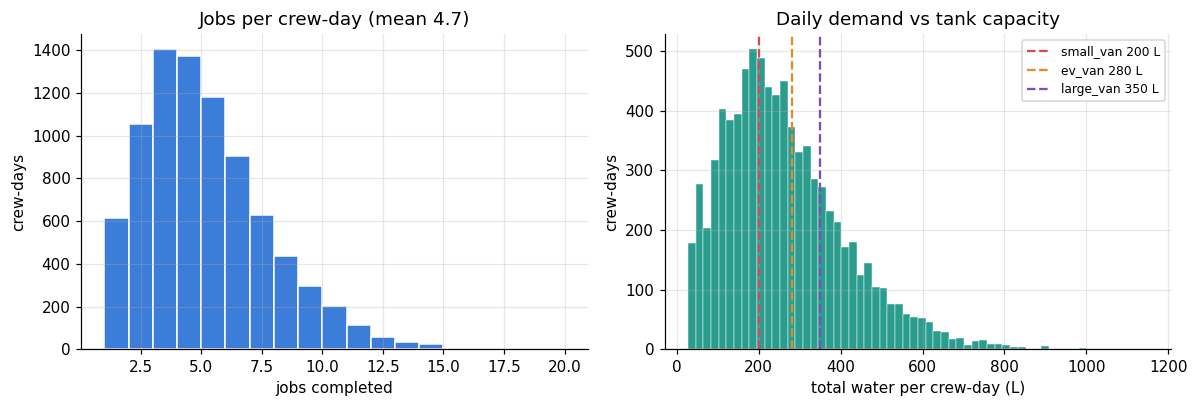

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist(crew_day.jobs, bins=range(1, 21), color='#3b7dd8', edgecolor='white')
ax[0].set_xlabel('jobs completed'); ax[0].set_ylabel('crew-days')
ax[0].set_title(f'Jobs per crew-day (mean {crew_day.jobs.mean():.1f})')

ax[1].hist(crew_day.water, bins=60, color='#2a9d8f', edgecolor='white', linewidth=0.3)
for cap, c in zip([200, 280, 350], ['#d1495b', '#e08b2f', '#7b4fb5']):
    name = vehicles.loc[vehicles.capacity_litres == cap, 'vehicle_type'].iloc[0]
    ax[1].axvline(cap, color=c, lw=1.5, ls='--', label=f'{name} {cap} L')
ax[1].set_xlabel('total water per crew-day (L)'); ax[1].set_ylabel('crew-days')
ax[1].legend(fontsize=8); ax[1].set_title('Daily demand vs tank capacity')
plt.tight_layout(); plt.savefig(f'{PLOT_PATH}/06_crew_day_load.png', bbox_inches='tight')
plt.show()

**Observation — arguably the most consequential finding for the module.** A crew completes
4.7 jobs per day on average (median 4, up to 19) and consumes **262 L per day on average**.
Against the tank capacities in `vehicles.csv`, that means **61% of crew-days exceed the
200 L small van, 39% exceed the 280 L EV van and 24% exceed the 350 L large van**.

A single tank does **not** cover a typical working day for any vehicle in the fleet. The A7
question is therefore not only "how many jobs per tank" but implicitly "how many refills per
day", and that reframing is what A12 needs from us.

## 13. Tank feasibility — how many jobs fit in one tank

Three ways to answer, giving three different numbers. The naive mean-based figure is the one
to argue *against*.

In [30]:
mu = df.water_litres.mean()
p95 = df.water_litres.quantile(0.95)
mx = df.water_litres.max()
print(f'per-job water: mean {mu:.2f} L | p95 {p95:.1f} L | max {mx:.1f} L\n')

rows = []
for _, v in vehicles.sort_values('capacity_litres').iterrows():
    rows.append({'vehicle': v.vehicle_type, 'capacity_L': v.capacity_litres,
                 'mean_based': int(v.capacity_litres // mu),
                 'p95_based': int(v.capacity_litres // p95),
                 'worst_case': int(v.capacity_litres // mx)})
pd.DataFrame(rows).set_index('vehicle')

per-job water: mean 55.68 L | p95 79.9 L | max 103.6 L



,capacity_L,mean_based,p95_based,worst_case
vehicle,,,,
small_van,200,3,2,1
ev_van,280,5,3,2
large_van,350,6,4,3


In [31]:
# Probabilistic view: resample real jobs and ask how often n jobs actually fit.
rng = np.random.default_rng(SEED)
water = df.water_litres.values
N_DRAWS = 20000

feas = {}
for _, v in vehicles.sort_values('capacity_litres').iterrows():
    feas[f'{v.vehicle_type} ({v.capacity_litres} L)'] = [
        (rng.choice(water, size=(N_DRAWS, n), replace=True).sum(axis=1) <= v.capacity_litres).mean()
        for n in range(1, 9)]

feas_df = pd.DataFrame(feas, index=pd.Index(range(1, 9), name='jobs_in_tank'))
print('P(all n jobs fit in one tank), empirical resampling:')
print((feas_df * 100).round(1).to_string())

P(all n jobs fit in one tank), empirical resampling:
              small_van (200 L)  ev_van (280 L)  large_van (350 L)
jobs_in_tank                                                      
1                         100.0           100.0              100.0
2                         100.0           100.0              100.0
3                          90.9           100.0              100.0
4                          21.1            97.7              100.0
5                           0.2            53.7               98.8
6                           0.0             4.6               68.8
7                           0.0             0.0               13.5
8                           0.0             0.0                0.4


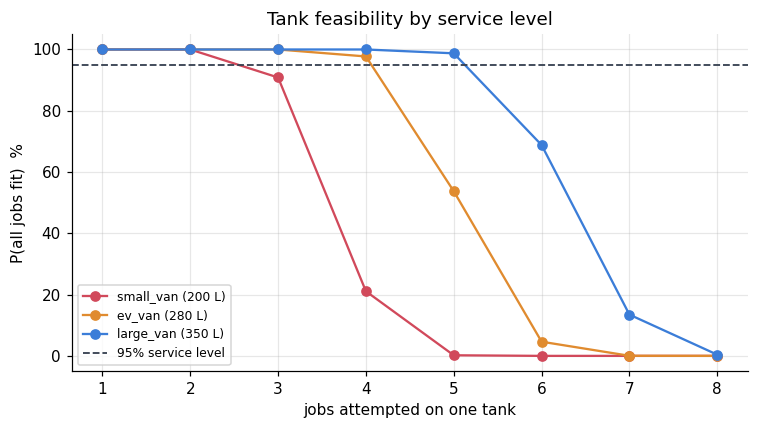

In [32]:
fig, ax = plt.subplots(figsize=(7, 4))
for col, c in zip(feas_df.columns, ['#d1495b', '#e08b2f', '#3b7dd8']):
    ax.plot(feas_df.index, feas_df[col] * 100, 'o-', color=c, label=col)
ax.axhline(95, ls='--', lw=1.2, color='#374151', label='95% service level')
ax.set_xlabel('jobs attempted on one tank'); ax.set_ylabel('P(all jobs fit)  %')
ax.set_title('Tank feasibility by service level'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f'{PLOT_PATH}/07_tank_feasibility.png', bbox_inches='tight')
plt.show()

**Observation.** The answer to "maximum jobs per tank" depends entirely on the service level
demanded, and the naive mean-based figure is **not safe**:

- small van (200 L): mean-based arithmetic says 3 jobs, but 3 jobs only fit 91% of the time —
  at a 95% service level the honest answer is **2**;
- EV van (280 L): mean-based says 5, but 5 jobs fit only 53% of the time — at 95% it is **4**;
- large van (350 L): mean-based says 6, but 6 jobs fit 69% of the time — at 95% it is **5**.

Reporting a single mean-derived number would overstate capacity on every vehicle. This is the
argument for delivering `consumption_model.csv` with an **interval**, and for stating the
jobs-per-tank figure **together with its service level** — which also satisfies the handbook's
"metrics must include spread, not just one number" requirement.

Note these are *unconditional* draws. Once the day's actual bookings are known (vehicle sizes
and interior add-ons are known at booking), the planning-time model gives a tighter,
job-specific answer. Building that properly is Week 4–6 work; this section only establishes
the reference figures.

## 14. Summary of findings

Findings are stated only where this notebook computed them.

> **Correction (2026-09-12).** F1–F4 previously quoted figures that disagreed with the cells
> above: the `interior_clean` share and effect size, the two models' scores, and the noise
> floor for interior jobs. They have been restated from this notebook's own outputs. The
> analysis and its conclusions are unchanged.

**F1 — `slot_type` is a decoy; the real service driver is hidden in `items`.**
All five slot types average 54.9–55.8 L. The water-relevant variable is the `interior_clean`
add-on (+18.0 L, present on 27.9% of jobs, sold across every slot type). Any feature set
built from `slot_type` without parsing `items` will miss the second-largest effect available
at booking time.

**F2 — dirtiness multiplies, the interior add-on adds.**
Dirtiness scales the vehicle-size base by an identical 1.00 / 1.18 / 1.35 / 1.53 across all
three vehicle sizes, while `interior_clean` contributes a flat ≈18 L irrespective of size or
dirtiness. A purely additive linear model is therefore mis-specified and needs a
size × dirtiness interaction.

**F3 — `dirtiness_level` is unknowable at planning time, and unpredictable from anything else.**
It is uncorrelated with rain (−0.007) and temperature (+0.001), flat across months, and
within-customer variation (sd 0.89) swamps between-customer variation (sd 0.28). It behaves
as an independent draw (20/40/30/10%). This forces A7 into two models — a planning-time model
(R² ≈ 0.72, MAE ≈ 5.9 L) and an on-site model (R² ≈ 0.95, MAE ≈ 2.4 L) — and makes tank
planning inherently probabilistic.

**F4 — the noise floor is additive and identical for both job types.**
Within an exact feature cell, exterior-only jobs scatter with sd ≈ 3.0 L and interior jobs
with sd ≈ 3.0 L — constant regardless of cell mean, so the noise is additive rather than
proportional. The wider ≈ 7.3 L spread at planning time is unresolved dirtiness and applies
to both job types equally, making it a property of the prediction stage rather than of
interior jobs.

**F5 — one tank does not cover a working day.**
Crews average 4.7 jobs and 262 L per day. 61% of crew-days exceed the 200 L small van, 39%
the 280 L EV van, 24% the 350 L large van. The module's framing must include refills, not
just a single jobs-per-tank number.

**F6 — mean-based tank arithmetic systematically overstates capacity.**
Mean-based division gives 3 / 5 / 6 jobs for the 200 / 280 / 350 L vans, but those loads
actually fit only 91% / 53% / 69% of the time. At a 95% service level the defensible figures
are 2 / 4 / 5. The deliverable must carry a service level alongside the number.

**Supporting negative results.** `jobs_done.csv` is complete (no missing values, no duplicate
rows) and joins one-to-one with the 39,302 completed bookings; the planted 3 Sep 2024
duplicate glitch never enters `jobs_done`, so A7 is insulated from it. No data-quality
outliers were found — the 0.57% beyond the Tukey fence are legitimate large/dirty/interior
combinations. `zone`, `is_weekend`, `distance_km` and calendar time carry no per-job water
signal. `duration_minutes`, `late_minutes` and `rating` are job *outcomes* and are excluded
as leakage.

### What this implies for the next steps

1. **Baseline (Week 4)** — global mean (MAE ≈ 11.2 L) then a per-vehicle-size group mean;
   both are beaten by any sensible model, which is the point of a baseline.
2. **Feature set** — parse `items`; use `vehicle_size` + `interior_clean` for the
   planning-time model and add `dirtiness_level` with an interaction for the on-site model.
   Exclude all post-job columns.
3. **Model family** — the structure is smooth and low-dimensional; linear-with-interaction
   and a tree ensemble should both be tried, and the ensemble should not be assumed better.
4. **Deliverable** — `consumption_model.csv` should carry a predicted interval, and the
   jobs-per-tank figure must be quoted with its service level.
5. **For A12** — pass the per-job distribution, not just the mean, plus the refill-frequency
   implication from F5.